# Explore PSF Effects

Sampling:
1. Density or total -> total in bin
1. Sampling: point is ben center or bin edge -> start with bin edge

---

1. Create a Moffat PSF Cube per some simple rules
    1. fixed beta
    1. fwhm/alpha/EE50/EE80 parameterized as function of wavelength
    1. spatial extent and oversample
    1. spectral extend, resolution element, and oversample
1. Apply Atmospheric dispersion: Use AD relation to compute grid shifts (with input angle and ZD at each wavelength and shift cube)
1. Apply a field rotation
    1. Assume rotator has some offset and angular error from desired orientation. take convention that 0 positions PA along slit
1. Apply ADC correction: shift back with opposite AD shift computed with a small parameterize angle error and add in emprical optical correction residuals
1. Clip out what makes it through a slit


In [2]:
from astropy.utils.masked.function_helpers import zeros_like


def Z(T,p,xw): #compressibility
    t=T-273.15
    a0 = 1.58123e-6   #K·Pa^-1
    a1 = -2.9331e-8   #Pa^-1
    a2 = 1.1043e-10   #K^-1·Pa^-1
    b0 = 5.707e-6     #K·Pa^-1
    b1 = -2.051e-8    #Pa^-1
    c0 = 1.9898e-4    #K·Pa^-1
    c1 = -2.376e-6    #Pa^-1
    d  = 1.83e-11     #K^2·Pa^-2
    e  = -0.765e-8    #K^2·Pa^-2
    return 1-(p/T)*(a0+a1*t+a2*t**2+(b0+b1*t)*xw+(c0+c1*t)*xw**2) + (p/T)**2*(d+e*xw**2)


def n(lam,t,p,h,xc):
    # lam: wavelength, 0.3 to 1.69 μm 
    # t: temperature, -40 to +100 °C
    # p: pressure, 80000 to 120000 Pa
    # h: fractional humidity, 0 to 1
    # xc: CO2 concentration, 0 to 2000 ppm

    σ = 1/lam           #μm^-1
    
    T= t + 273.15     #Temperature °C -> K
    
    R = 8.314510      #gas constant, J/(mol·K)
    
    k0 = 238.0185     #μm^-2
    k1 = 5792105      #μm^-2
    k2 = 57.362       #μm^-2
    k3 = 167917       #μm^-2
 
    w0 = 295.235      #μm^-2
    w1 = 2.6422       #μm^-2
    w2 = -0.032380    #μm^-4
    w3 = 0.004028     #μm^-6
    
    A = 1.2378847e-5  #K^-2
    B = -1.9121316e-2 #K^-1
    C = 33.93711047
    D = -6.3431645e3  #K
    
    α = 1.00062
    β = 3.14e-8       #Pa^-1,
    γ = 5.6e-7        #°C^-2

    #saturation vapor pressure of water vapor in air at temperature T (Pa)
    svp = np.where(t>=0,
        np.exp(A*T**2 + B*T + C + D/T), # if t>=0
        10**(-2663.5/T+12.537))         # if t<0
    
    #enhancement factor of water vapor in air
    f = α + β*p + γ*t**2
    
    #molar fraction of water vapor in moist air
    xw = f*h*svp/p
    
    #refractive index of standard air at 15 °C, 101325 Pa, 0% humidity, 450 ppm CO2
    nas = 1 + (k1/(k0-σ**2)+k3/(k2-σ**2))*1e-8
    
    #refractive index of standard air at 15 °C, 101325 Pa, 0% humidity, xc ppm CO2
    naxs = 1 + (nas-1) * (1+0.534e-6*(xc-450))
    
    #refractive index of water vapor at standard conditions (20 °C, 1333 Pa)
    nws = 1 + 1.022*(w0+w1*σ**2+w2*σ**4+w3*σ**6)*1e-8
    
    Ma = 1e-3*(28.9635 + 12.011e-6*(xc-400)) #molar mass of dry air, kg/mol
    Mw = 0.018015                            #molar mass of water vapor, kg/mol
    
    Za = Z(288.15, 101325, 0)                #compressibility of dry air
    Zw = Z(293.15, 1333, 1)                  #compressibility of pure water vapor
    
    #Eq.4 with (T,P,xw) = (288.15, 101325, 0)
    ρaxs = 101325*Ma/(Za*R*288.15)           #density of standard air
    
    #Eq 4 with (T,P,xw) = (293.15, 1333, 1)
    ρws  = 1333*Mw/(Zw*R*293.15)             #density of standard water vapor
    
    # two parts of Eq.4: ρ=ρa+ρw
    ρa   = p*Ma/(Z(T,p,xw)*R*T)*(1-xw)       #density of the dry component of the moist air    
    ρw   = p*Mw/(Z(T,p,xw)*R*T)*xw           #density of the water vapor component
    
    nprop = 1 + (ρa/ρaxs)*(naxs-1) + (ρw/ρws)*(nws-1)
    
    return nprop


In [27]:
from enum import Enum
import astropy.units as u
from astropy.modeling.models import Moffat2D
import numpy as np
from scipy.interpolate import make_interp_spline, RegularGridInterpolator
import skimage as ski
import matplotlib.pyplot as plt



class PSFScale(Enum):
    FWHM = 'fwhm'
    EE50 = 'ee50'
    EE80 = 'ee80'
    gamma = 'gamma'  # astropy scale factor
    alpha = 'alpha'  # wikipedia scale factor


def make_wavlength_grid(min_wave, max_wave, resolving_power=20e3, osample=4, bin_edge=True):
    """
    Make a wavelength grid in constant resolving power space with oversampling factor

    Args:
        MIN_WAVE:
        MAX_WAVE:
        resolving_power:
        osample:
        bin_edge:

    Returns:

    """
    # TODO deal with edge vs center
    rosamp = resolving_power*osample
    return min_wave * (1 + 1/rosamp) ** np.arange(int(np.log(max_wave/min_wave)/np.log(1+1/(rosamp)))+1)


def make_spatial_grid(x_extent, y_extent:u.Quantity, plate_scale:u.Quantity, osample=10, bin_edge=False):
    """
    Make a spatial grid with the specified extent and sampling with oversampling factor
    Args:
        x_extent:
        y_extent:
        plate_scale:
        osample:

    Returns:

    """
    x=np.linspace(-x_extent/2, x_extent/2, num=int((x_extent/plate_scale*osample).to(u.dimensionless_unscaled).value))
    y=np.linspace(-y_extent/2, y_extent/2, num=int((y_extent/plate_scale*osample).to(u.dimensionless_unscaled).value))
    #TODO handle bin edge or not
    return  u.Quantity(np.meshgrid(x, y)).to(u.mas)


def ao_scale(wavelengths: u.Quantity) -> u.Quantity:

    global FWHM_AO
    try:
        return FWHM_AO(wavelengths)
    except NameError:
        SKYBANDS = (np.array([300, 400])*u.nm,
                 np.array([395, 505])*u.nm,
                 np.array([495, 635])*u.nm,
                 np.array([625, 800])*u.nm,
                 np.array([785, 1000])*u.nm,
                 np.array([990, 1185])*u.nm,
                 np.array([1165, 1400])*u.nm,
                 np.array([1500, 1800])*u.nm,
                 np.array([2000, 2600])*u.nm)
        FWHM_AO=lambda x, *a, **kw: make_interp_spline([300]+list(map(lambda x : np.mean(x).value, SKYBANDS))[1:][:-1]+[2550],
                                                       [343, 357,220, 190, 185,183,182, 175, 182], k=1)(x.to(u.nm).value)*u.mas

    return  FWHM_AO(wavelengths)


def natural_scale(seeing:u.Quantity, zenith_angle: u.Quantity, wavelengths: u.Quantity, pivot=500*u.nm) -> u.Quantity:
    """
    Seeing law scaled to wavelength

    https://opg.optica.org/josa/fulltext.cfm?uri=josa-68-7-877&id=57124
    https://www.mdpi.com/2072-4292/14/2/405
    """
    return seeing * (wavelengths / pivot) ** -0.2 * 1/np.cos(zenith_angle.to(u.rad)) ** .6


def psf_moffat(scale:u.Quantity|float, beta:float, spatial_grid:u.Quantity, scaletyppe: PSFScale=PSFScale.FWHM):

    if scaletyppe == PSFScale.FWHM:
        # theta = theta_factor*FWHM, specific to Moffat PSF
        theta_factor = 0.5 / (2 ** (1. / beta) - 1.) ** .5
        gamma = theta_factor * scale
    elif scaletyppe in (PSFScale.gamma, PSFScale.alpha):
        gamma = scale
    else:
        raise NotImplementedError("scale type not implemented")

    amplitude = (beta-1)/np.pi/gamma[None, None, :].to(u.mas)**2

    cube = Moffat2D.evaluate(spatial_grid[0][...,None].to(u.mas), spatial_grid[1][...,None].to(u.mas),
                             amplitude, x_0=0, y_0=0, gamma=gamma[None, None, :].to(u.mas), alpha=beta)

    grid_step = spatial_grid[:,1,1]-spatial_grid[:,0,0]
    grid_area = np.prod(grid_step.value) * spatial_grid.unit**2
    norm = cube.sum(0).sum(0)*grid_area
    if norm.max()<.99:
        raise ValueError('use a bigger grid')
    cube/=norm

    return cube


def psf_cube(seeing:u.Quantity, zenith_angle: u.Quantity, spatial_grid, wavelength_grid: u.Quantity, ao=False, AO_BETA=3.25, NATURAL_BETA=4.765) -> np.array:
    return psf_moffat(ao_scale(wavelength_grid) if ao else natural_scale(seeing, zenith_angle, wavelength_grid),
               AO_BETA if ao else NATURAL_BETA,
               spatial_grid,
               scaletyppe=PSFScale.FWHM if ao else PSFScale.FWHM)

def n_air(wavelengths:u.Quantity):
    # TODO
    # see https://github.com/polyanskiy/refractiveindex.info-scripts/blob/main/scripts/Ciddor%201996%20-%20air.py
    # see https://github.com/polyanskiy/refractiveindex.info-scripts/blob/main/scripts/Mathar%202007%20-%20Air%207.5-14.1um.py
    # # https://github.com/polyanskiy/refractiveindex.info-scripts/blob/main/scripts/Birch%201994%20-%20air.py
    return n(wavelengths.to(u.um).value,15,101325,0,450) #dry air, 15 °C, 450 ppm

def ad_shift(zenith_angle: u.Quantity, wavelengths: u.Quantity, wave_ref: u.Quantity)-> u.Quantity:
    shifts = 206265*(n_air(wavelengths)-n_air(wave_ref))*np.tan(zenith_angle.to(u.rad).value)*u.arcsec
    return shifts.to(u.mas)


def apply_field_rotation(cube, angle: u.Quantity, miscentration: u.Quantity, angle_error: u.Quantity, spatial_grid:u.Quantity)-> u.Quantity:
    """
    Rotate input cube about angle+angle_error centered miscentration offset from its center

    Args:
        angle:
        miscentration:
        angle_error:

    Returns:

    """

    grid_step_size = spatial_grid[:,1,1]-spatial_grid[:,0,0]
    center = ((u.Quantity(miscentration)/grid_step_size).to(u.dimensionless_unscaled).value+np.array(spatial_grid.shape[1:])/2)[::-1]
    return ski.transform.rotate(cube, (angle+ angle_error).to(u.deg).value, center=center, order=1, mode='edge')*cube.unit


def adc_correction(zenith_angle: u.Quantity, adc_zenith_error: u.Quantity, wavelengths: u.Quantity, wave_ref: u.Quantity,
                   broadband=True, resid_only=False)-> u.Quantity:
    """
    Computer a correction for zenith angle
    Args:
        adc_zenith_angle:
        wavelengths:

    Returns:

    """

    #LRIS design note residuals
    Z=np.array([0.,55.,60.])
    lam_um=np.array([0.31,0.32,0.36,0.40,0.45,0.50,0.56,0.63,0.70,0.79,0.88,0.98,1.10])
    R=np.array([[0,0,0,0,0,0,0,0,0,0,0,0,0],
                [-0.068,-0.057,0.017,0.016,0.052,0.052,0.052,0.059,0.041,0.031,-0.007,-0.063,-0.120],
                [-0.083,-0.070,0.020,0.018,0.062,0.062,0.062,0.071,0.049,0.036,-0.009,-0.077,-0.146]])

    adc_opt_resid = RegularGridInterpolator((Z,lam_um),R,method="linear",bounds_error=False,fill_value=None)

    adc_nir_resid = lambda xy: adc_opt_resid((xy[0], (xy[1]-1)/1.5*(1.1-.31)+.31))  #scale to nIR

    #300-500 & 500-1000
    adc_ub_resid = lambda xy: adc_opt_resid((xy[0], (xy[1]-.3)/.2*(1.1-.31)+.31))/2  #scale
    adc_gri_resid = lambda xy: adc_opt_resid((xy[0], (xy[1]-.5)/.5*(1.1-.31)+.31))/2  #scale to nIR


    if resid_only:
        shifts = np.zeros_like(wavelengths.value)*u.mas
    else:
        shifts = -ad_shift(zenith_angle+adc_zenith_error, wavelengths, wave_ref)

    if broadband:
        use = wavelengths<1000*u.nm
        shifts[use] += adc_opt_resid((zenith_angle.to_value(u.deg), wavelengths[use].to_value(u.um)))*1000*u.mas
    else:
        use = wavelengths<500*u.nm
        shifts[use] += adc_ub_resid((zenith_angle.to_value(u.deg), wavelengths[use].to_value(u.um)))*1000*u.mas
        use = ~use & (wavelengths<1000*u.nm)
        shifts[use] += adc_gri_resid((zenith_angle.to_value(u.deg), wavelengths[use].to_value(u.um)))*1000*u.mas
    use = wavelengths>=1000*u.nm
    shifts[use] += adc_nir_resid((zenith_angle.to_value(u.deg), wavelengths[use].to_value(u.um)))*1000*u.mas

    return shifts.to(u.mas)


def apply_slit(cube:np.ndarray, spatial_grid:u.Quantity, slit_width:u.Quantity, slit_height:u.Quantity, slit_miscentration: u.Quantity)-> np.ndarray:
    """
    Clip out the portion of the cube that is in the slit

    Args:
        cube:
        spatial_grid:
        slit_width:
        slit_height:
        slit_miscentration:

    Returns:

    """
    shifted = np.abs(spatial_grid+slit_miscentration[:, None, None])
    in_slit = (shifted[1] < slit_height/2) & (shifted[0] < slit_width/2)

    xs, ys = np.nonzero(in_slit)
    x0, x1 = xs.min(), xs.max() + 1
    y0, y1 = ys.min(), ys.max() + 1

    return cube[x0:x1, y0:y1, :]


def apply_roundapp(cube:np.ndarray, spatial_grid:u.Quantity, diam:u.Quantity, miscentration: u.Quantity)-> np.ndarray:
    """
    Clip out the portion of the cube that is in a round aperture

    Args:
        cube:
        spatial_grid:
        slit_width:
        slit_height:
        slit_miscentration:

    Returns:

    """
    shifted = np.abs(spatial_grid+slit_miscentration[:, None, None])
    in_slit = (shifted[1]**2+shifted[0]**2)<((diam/2)**2)

    xs, ys = np.nonzero(in_slit)
    x0, x1 = xs.min(), xs.max() + 1
    y0, y1 = ys.min(), ys.max() + 1

    return cube[x0:x1, y0:y1, :]


In [4]:
import numpy as np
from scipy.ndimage import map_coordinates

def shift_cube_xy_mapcoords_chunked(
    psf: np.ndarray,
    dy: np.ndarray,
    dx: np.ndarray,
    *,
    chunk_w: int = 8,
    order: int = 3
) -> np.ndarray:
    """
    Shift each wavelength plane psf[:, :, w] by (dx[w], dy[w]) using interpolation.

    psf: (nx, ny, nwave)
    dy:  (nwave,)   shift along y (axis=1), in pixels (float ok)
    dx:  (nwave,)   shift along x (axis=0), in pixels (float ok); optional

    Sign convention:
      Positive dy moves the image toward +y (increasing y index).
      Positive dx moves the image toward +x (increasing x index).
    """
    nx, ny, nw = psf.shape

    dy = np.asarray(dy, dtype=np.float32)
    if dy.shape != (nw,):
        raise ValueError(f"dy must have shape (nwave,) == ({nw},), got {dy.shape}")

    dx = np.asarray(dx, dtype=np.float32)
    if dx.shape != (nw,):
        raise ValueError(f"dx must have shape (nwave,) == ({nw},), got {dx.shape}")

    # Base grid for a single chunk (broadcasted)
    xi = np.arange(nx, dtype=np.float32)[:, None, None]  # (nx, 1, 1)
    yi = np.arange(ny, dtype=np.float32)[None, :, None]  # (1, ny, 1)

    out = np.empty_like(psf)

    # prefilter only matters for spline order > 1
    prefilter = (order > 1)

    for w0 in range(0, nw, chunk_w):
        w1 = min(w0 + chunk_w, nw)
        k = w1 - w0

        # wave index grid for this chunk
        wi = np.arange(w0, w1, dtype=np.float32)[None, None, :]   # (1, 1, k)

        # To shift content by +dx/+dy, we sample input at (x - dx, y - dy).
        # (map_coordinates samples the input at given coordinates)
        xcoords = xi - dx[w0:w1][None, None, :]                   # (nx, 1, k) -> broadcast to (nx, ny, k)
        ycoords = yi - dy[w0:w1][None, None, :]                   # (1, ny, k) -> broadcast to (nx, ny, k)

        # Broadcast to full chunk volume
        xcoords = np.broadcast_to(xcoords, (nx, ny, k))
        ycoords = np.broadcast_to(ycoords, (nx, ny, k))
        wcoords = np.broadcast_to(wi,      (nx, ny, k))

        coords = np.array([xcoords, ycoords, wcoords], dtype=np.float32)  # (3, nx, ny, k)

        out[:, :, w0:w1] = map_coordinates(psf, coords, order=order, mode='nearest', prefilter=prefilter)*psf.unit

    return out


## Grid

In [5]:
MAX_PSF_WIDTH = 1.2e3*u.mas
SLIT_LENGTH = 10e3*u.mas
MIN_WAVE = 310*u.nm
MAX_WAVE = 2450*u.nm
PLATE_SCALE = 50*u.mas

wave_ref=500*u.nm
wavelengths = make_wavlength_grid(MIN_WAVE, MAX_WAVE, resolving_power=10, osample=3)
sky_points = make_spatial_grid(5*MAX_PSF_WIDTH, SLIT_LENGTH+4*MAX_PSF_WIDTH, plate_scale=PLATE_SCALE, osample=4)
sky_step_size = sky_points[:,1,1]-sky_points[:,0,0]
sky_step_area = np.prod(sky_step_size.value) * sky_points.unit**2
print(f'PSF Cube needs {sky_points.size*wavelengths.size*8/1024**3:.0f} GiB')

PSF Cube needs 1 GiB


## Settings

In [11]:
ao_enabled = False

seeing = 650*u.mas
zenith_angle = 0 * u.deg
slit_width = 750 * u.mas if not ao_enabled else 325 * u.mas
slit_height = 10e3 *u.mas

rotator_miscentration = u.Quantity((45*u.mas, 45*u.mas))
slit_miscentration = u.Quantity((-60*u.mas, 0*u.mas))
rotator_error = 360/400 * u.deg
adc_zenith_error = 360/400 * u.deg

## Base PSF

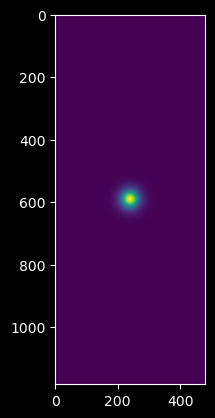

In [12]:
psf = psf_cube(seeing, zenith_angle, sky_points, wavelengths, ao=ao_enabled)
plt.imshow(psf.sum(2).value)

## Shift PSF by Atmospheric Dispersion

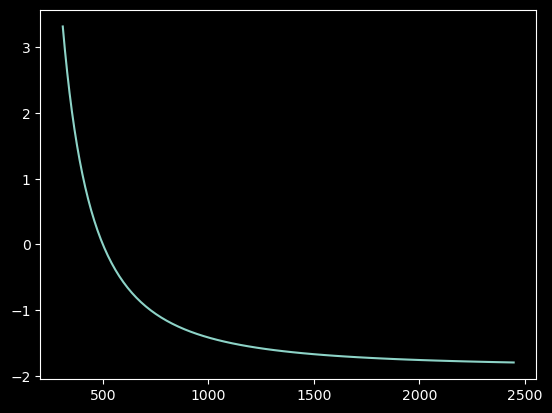

In [91]:
ad = ad_shift(zenith_angle, wavelengths, wave_ref)
plt.plot(wavelengths, ad.to('arcsec'))

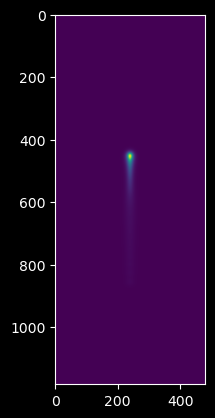

In [92]:
chunk_w = int(wavelengths.size/max(int(sky_points.size*wavelengths.size*4/1024**3),1))
shifted = shift_cube_xy_mapcoords_chunked(psf, np.zeros(ad.size), (ad/sky_step_size[1]).value, chunk_w=chunk_w)
plt.imshow(shifted.sum(2).value)

## (De)Rotate the field

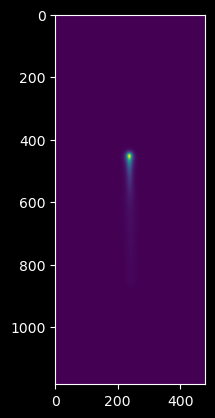

In [93]:
rotated = apply_field_rotation(shifted, 0*u.deg, rotator_miscentration, rotator_error, sky_points)
plt.imshow(rotated.sum(2).value)

## Shift PSF by ADC correction

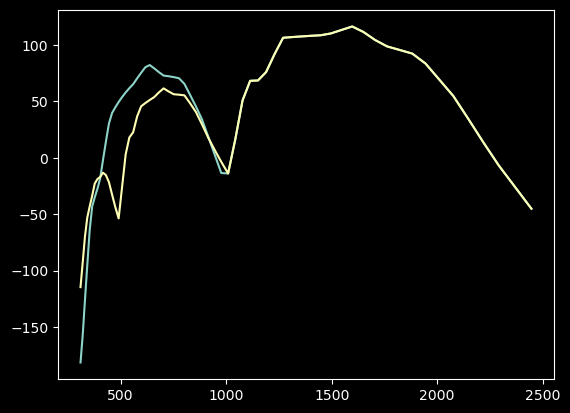

In [120]:
adc = adc_correction(zenith_angle, adc_zenith_error, wavelengths, wave_ref, broadband=True)
adc2 = adc_correction(zenith_angle, adc_zenith_error, wavelengths, wave_ref, broadband=False)
plt.plot(wavelengths, ad+adc)
plt.plot(wavelengths, ad+adc2)

In [121]:
chunk_w = int(wavelengths.size/max(int(sky_points.size*wavelengths.size*4/1024**3),1))
corrected = shift_cube_xy_mapcoords_chunked(rotated, np.zeros(adc.size), (adc/sky_step_size[1]).value, chunk_w=chunk_w)
corrected_2slit = shift_cube_xy_mapcoords_chunked(rotated, np.zeros(adc.size), (adc2/sky_step_size[1]).value, chunk_w=chunk_w)

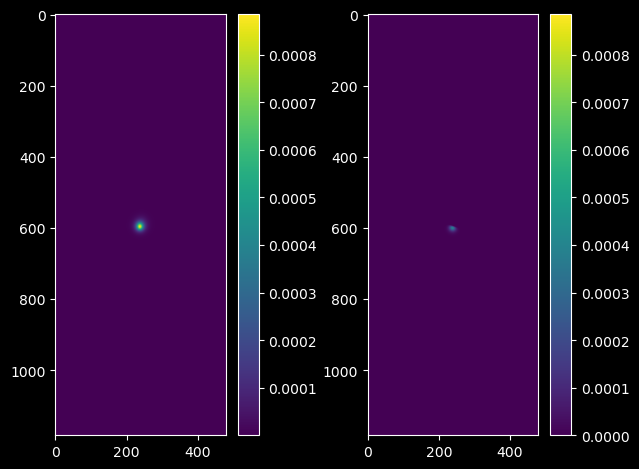

In [122]:
plt.subplot(121)
plt.imshow(corrected.sum(2).value)
plt.colorbar()
plt.subplot(122)
plt.imshow(corrected.sum(2).value-psf.sum(2).value, vmin=0, vmax=corrected.sum(2).value.max())
plt.colorbar()
plt.tight_layout()

## Apply the slit

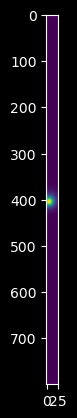

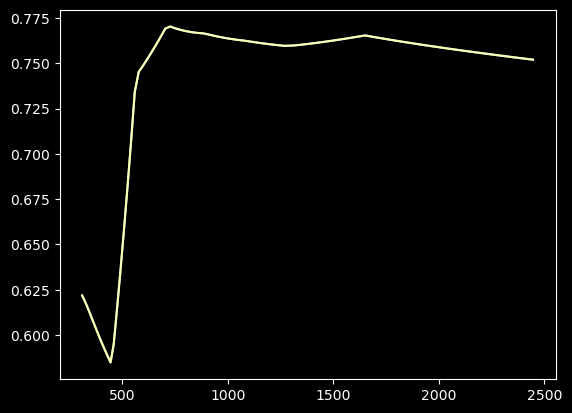

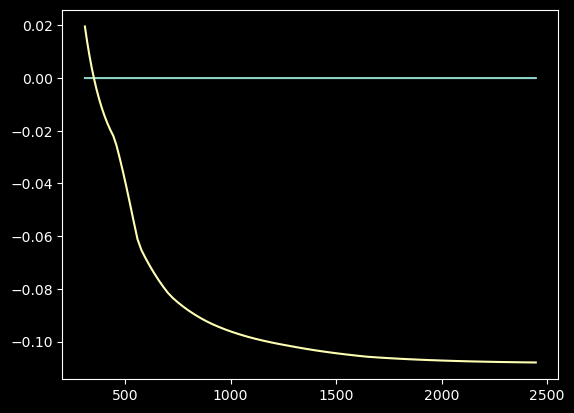

In [127]:
input_psf = apply_slit(corrected, sky_points, slit_width, slit_height, slit_miscentration)
input_psf2sl = apply_slit(corrected_2slit, sky_points, slit_width, slit_height, slit_miscentration)
input_psf2sl_nosliterror = apply_slit(corrected_2slit, sky_points, slit_width, slit_height, slit_miscentration*0)
plt.imshow(input_psf.sum(2).value)
plt.show()
plt.plot(wavelengths, input_psf.sum(axis=0).sum(axis=0)*sky_step_area, label='2 Slits')
plt.plot(wavelengths, input_psf2sl.sum(axis=0).sum(axis=0)*sky_step_area, label='3 Slits')
plt.show()
plt.plot(wavelengths, (input_psf-input_psf2sl).sum(axis=0).sum(axis=0)*sky_step_area, label='Diff')
plt.plot(wavelengths, (input_psf2sl-input_psf2sl_nosliterror).sum(axis=0).sum(axis=0)*sky_step_area, label='Diff vs perfect alignment')

## Whats the ratio of a round slit to a narrow slit?

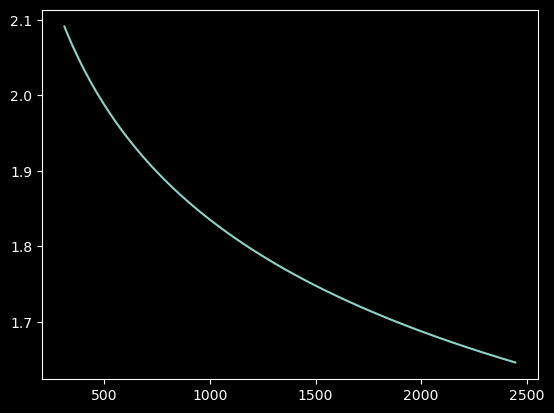

<Quantity 1.96588343>

In [29]:
b = apply_slit(psf, sky_points, slit_width/2, 1250*u.mas, slit_miscentration*0).sum(0).sum(0)*sky_step_area
c = apply_roundapp(psf, sky_points, 1200*u.mas, slit_miscentration[0]*0).sum(0).sum(0)*sky_step_area
plt.plot(wavelengths, c/b)
plt.title(f'Mean ration in optical: {(c/b)[wavelengths<1000*u.nm].mean():.2f}')
plt.show()